Código baseado no desenvolviemnto disponível em: https://www.kaggle.com/code/jeanmarques/rede-neural-para-imagens-termogr-ficas

In [1]:
from PIL import Image
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [2]:
#Leitura dos dados extraídos do repositório
tab = pd.read_csv("./dados/tabulares.csv", encoding='utf-8', low_memory=False)
caract = pd.read_csv("./dados/caracteristicas", encoding='utf-8', low_memory=False)
comp = pd.read_csv("./dados/complementares.csv", encoding='utf-8', low_memory=False)
#Junta dados
df = pd.merge(tab, caract, on='ID')
df = pd.merge(df, comp, on='ID')

In [3]:
df.head(3)

,ID,Records,Name,Age,Exams,Diagnosis,Data_registro,Estado_civil,Raca,Hábitos Alimentares,Temperatura,Menarca,Radioterapia,Cirurgia Plástica,Sinais
0,1,voluntária,private,72,thermography,unknown,2012-10-24,widow,pardo,Pobre em gordura,34.9,12,Não,Não,Não
1,2,77020,private,66,thermography,healthy,2012-10-30,married,pardo,Pobre em gordura,36.5,12,Não,Não,Não
2,3,voluntária,private,68,thermography,healthy,2012-10-30,single,black,Pobre em gordura,34.1,12,Não,Não,Não


In [4]:
#Traduzindo e padronizando algumas informações de características
df.Estado_civil = df.Estado_civil.str.replace('widow', 'viuva')
df.Estado_civil = df.Estado_civil.str.replace('married', 'casada')
df.Estado_civil = df.Estado_civil.str.replace('single', 'solteira')
df.Estado_civil = df.Estado_civil.str.replace('widow', 'viuva')
df.Estado_civil = df.Estado_civil.str.replace('viuvo', 'viuva')
df.Estado_civil = df.Estado_civil.str.replace('divorced', 'divorciada')
df.Estado_civil = df.Estado_civil.str.replace('casado', 'casada')
df.Estado_civil = df.Estado_civil.str.replace('divorciado', 'divorciada')
df.Estado_civil = df.Estado_civil.str.replace('solteiro', 'solteira')
df.Estado_civil = df.Estado_civil.str.replace('casada ', 'casada')
#
df.Raca = df.Raca.str.replace('black', 'negra')
df.Raca = df.Raca.str.replace('white', 'branca')
df.Raca = df.Raca.str.replace('mulattos', 'mulata')
df.Raca = df.Raca.str.replace('pardo', 'parda')

In [5]:
df.head(3)

,ID,Records,Name,Age,Exams,Diagnosis,Data_registro,Estado_civil,Raca,Hábitos Alimentares,Temperatura,Menarca,Radioterapia,Cirurgia Plástica,Sinais
0,1,voluntária,private,72,thermography,unknown,2012-10-24,viuva,parda,Pobre em gordura,34.9,12,Não,Não,Não
1,2,77020,private,66,thermography,healthy,2012-10-30,casada,parda,Pobre em gordura,36.5,12,Não,Não,Não
2,3,voluntária,private,68,thermography,healthy,2012-10-30,solteira,negra,Pobre em gordura,34.1,12,Não,Não,Não


In [6]:
#removendo dados irrelevantes para a análise e treinamento do modelo
lista_drop = ['Records', 'Name', 'Exams', 'Data_registro']
df = df.drop(lista_drop, axis=1)

In [7]:
#Retirando diagnósticos desconhecido
df_unknow = df.query(r"Diagnosis == 'unknown'")
df = df.query(r"Diagnosis != 'unknown'")
del df_unknow

In [8]:
df.count()

ID                     278
Age                    278
Diagnosis              278
Estado_civil           278
Raca                   278
Hábitos Alimentares    278
Temperatura            278
Menarca                278
Radioterapia           278
Cirurgia Plástica      278
Sinais                 278
dtype: int64

In [9]:
#Função para converter imagem para array
def convert_image(image_to_convert):
  
  image_to_convert = image_to_convert.convert('RGB')
  #redimenciona imagem
  image_to_convert = image_to_convert.resize((100,100))
  
  return np.asarray(image_to_convert)

In [10]:
def select_images(patient):
  #Define array para receber imagens da paciente
  patient_images_array = []
  #Atribui caminho base para pastas de imagens
  images_directory = './dados/imagens/'
  #De acordo com o id da paciente, monta nome e pesquisa pela pasta dela
  patient_directory = (images_directory + 'PACIENTE_' + str(patient).zfill(4))
  #Veririca a quantidade de imagens dentro da pasta da paciente
  list_images = os.listdir(patient_directory) 
  for i, image in enumerate(list_images):
    #instancia imagem
    termography = Image.open(patient_directory + '/' + image)
    #Converte imagem
    converted_image = convert_image(termography)
    patient_images_array.append(converted_image)
  print('Paciente: ' + str(patient).zfill(4) + ' processado')
  return(patient_images_array)

In [11]:
df['Imagens'] = df.ID.apply(select_images)

Paciente: 0002 processado
Paciente: 0003 processado
Paciente: 0004 processado
Paciente: 0005 processado
Paciente: 0006 processado
Paciente: 0007 processado
Paciente: 0008 processado
Paciente: 0009 processado
Paciente: 0010 processado
Paciente: 0011 processado
Paciente: 0012 processado
Paciente: 0013 processado
Paciente: 0015 processado
Paciente: 0016 processado
Paciente: 0017 processado
Paciente: 0018 processado
Paciente: 0019 processado
Paciente: 0020 processado
Paciente: 0021 processado
Paciente: 0022 processado
Paciente: 0023 processado
Paciente: 0024 processado
Paciente: 0026 processado
Paciente: 0028 processado
Paciente: 0030 processado
Paciente: 0031 processado
Paciente: 0032 processado
Paciente: 0034 processado
Paciente: 0035 processado
Paciente: 0036 processado
Paciente: 0037 processado
Paciente: 0038 processado
Paciente: 0040 processado
Paciente: 0041 processado
Paciente: 0042 processado
Paciente: 0043 processado
Paciente: 0044 processado
Paciente: 0045 processado
Paciente: 00

In [12]:
#Verificando quantos pacientes estão saudáveis (healthy) e doentes (sick)
df.Diagnosis.value_counts()

Diagnosis
healthy    178
sick       100
Name: count, dtype: int64

In [ ]:
df.Imagens.value_counts()

In [13]:
lb = LabelBinarizer()
df['Diagnosis'] = lb.fit_transform(df['Diagnosis'])
df.Diagnosis.value_counts()

Diagnosis
0    178
1    100
Name: count, dtype: int64

In [14]:
print(df.Radioterapia.value_counts())
print(df.Sinais.value_counts())
df['Cirurgia Plástica'].value_counts()

Radioterapia
Não    235
Sim     43
Name: count, dtype: int64
Sinais
Não    206
Sim     72
Name: count, dtype: int64


Cirurgia Plástica
Não    257
Sim     21
Name: count, dtype: int64

In [15]:
df.Radioterapia = lb.fit_transform(df.Radioterapia)

df['Sinais'] = lb.fit_transform(df['Sinais'])

df['Cirurgia Plástica'] = lb.fit_transform(df['Cirurgia Plástica'])

print(df.Radioterapia.value_counts())
print(df.Sinais.value_counts())
df['Cirurgia Plástica'].value_counts()

Radioterapia
0    235
1     43
Name: count, dtype: int64
Sinais
0    206
1     72
Name: count, dtype: int64


Cirurgia Plástica
0    257
1     21
Name: count, dtype: int64

In [16]:
#Variáveis não binárias

print(df['Estado_civil'].value_counts())
print(df['Raca'].value_counts())
print(df['Hábitos Alimentares'].value_counts())


Estado_civil
casada        125
solteira       95
viuva          37
divorciada     21
Name: count, dtype: int64
Raca
branca      101
parda        85
negra        77
amarela      13
indigena      1
mulata        1
Name: count, dtype: int64
Hábitos Alimentares
Pobre em gordura    214
Rica em gordura      43
Sem gordura          21
Name: count, dtype: int64


In [17]:
#Faz o mesmo com dados categóricos que não são binários
l_encoder = preprocessing.LabelEncoder()

df['Estado_civil'] = l_encoder.fit_transform(df['Estado_civil'])

df['Raca'] = l_encoder.fit_transform(df['Raca'])

df['Hábitos Alimentares'] = l_encoder.fit_transform(df['Hábitos Alimentares'])

print(df['Estado_civil'].value_counts())
print(df['Raca'].value_counts())
print(df['Hábitos Alimentares'].value_counts())

Estado_civil
0    125
2     95
3     37
1     21
Name: count, dtype: int64
Raca
1    101
5     85
4     77
0     13
2      1
3      1
Name: count, dtype: int64
Hábitos Alimentares
0    214
1     43
2     21
Name: count, dtype: int64


In [14]:
def separa_df(dataframe):
  imagens = []
  diagnostico = []
  for i in range(dataframe.shape[0]):
    for imagem in (dataframe.iloc[i,1]):
        imagens.append(imagem)
        diagnostico.append(dataframe.iloc[i,0])
      
  return(imagens, diagnostico) 

In [15]:
#cria novo dataframe apenas com as imagens e os diagnósticos
new_df = df[['Diagnosis','Imagens']]

imagens, diagnosticos = separa_df(new_df)

imagens = np.array(imagens)
diagnosticos = np.array(diagnosticos)

In [16]:
#verificando se os tamnhos coincidem 
len(imagens), len(diagnosticos)

(7245, 7245)

In [21]:
diagnosticos

array([0, 0, 0, ..., 1, 1, 1])

In [18]:
#CALLBACKS
#São funções que podem ser passadas nos métodos do Keras para se integrar e auxiliar várias etapas do ciclo de vida do treinamento
#ModelCheckpoint: serve para salvar o modelo com uma certa frequência. Útil caso ocorra algum problema durante o processamento.
#https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
#ReduceLROnPlateau: Reduz a taxa de aprendizado quando alguma métrica para de melhorar com o avanço do treinamento. Muitos modelos se beneficiam ao reduzer a taa de aprendizado em 20%

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping


In [19]:
#Definindo hiperparâmetros do modelo
batch_size   = 32
#Tamanho da imagem
input_shape  = (100, 100, 3)
#
random_state = 42
delta        = 1e-5
epoch        = 10

In [21]:
'''
path: onde será salvo o modelo
monitor: métrica a ser monitorada (acurácia)
verbose: (1) mostra na barra de progresso
save_best_only: Salvar somente o melhor modelo
mode: Queremos a máxima acurácia.
'''
###
path='transferlearning_weights.keras'
checkpoint = ModelCheckpoint(path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

In [36]:

#monitor: valor observado (acurácia)
#factor: fator de redução
#min-delta: limiar para medir o novo ótimo, para focar apenas em mudanças significativas
#patience: número de épocas sem evolução do modelo
#verbose = 1: mostra mensagens de atualização
lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, min_delta=delta, patience=5, verbose=1)
e_stopping = EarlyStopping(monitor="val_loss",
    min_delta=delta,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,)
callbacks = [checkpoint, lr_reduce, e_stopping]

In [40]:
print(callbacks)

[<keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x0000027BEF183590>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x0000027BA2098BD0>]


In [23]:
#Separa em treino e teste numa proporção de 70/30
(x_train, x_test, y_train, y_test) = train_test_split(imagens, diagnosticos, test_size=0.30, stratify=diagnosticos, random_state=random_state)

In [25]:
print(y_train)
print(y_test)

[1 1 1 ... 1 0 0]
[1 0 0 ... 0 1 0]


In [26]:
from tensorflow.keras.applications.vgg19 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

data_aug = val_datagen.flow(x_test, y_test, batch_size=batch_size)

In [27]:
x_batch, y_batch = next(data_aug)

print(x_batch.shape)
print(y_batch.shape)

(32, 100, 100, 3)
(32,)


In [30]:
#Data augmentation
#gera mais diversidade de dados, sem necessidade de fazer novas coletas
#train_datagen = ImageDataGenerator(
#        rotation_range=10,
#        zoom_range=0.1)

#data_aug = train_datagen.flow(x_train, y_train, batch_size=batch_size)

In [28]:
#transfer learning
#aproveita uma modelo treinado anteriormente
conv_base = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#Retreinando parte da VGG19
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False
#

conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [30]:
#Instanciando modelo
    
model = models.Sequential()
model.add(conv_base)
model.add(layers.GlobalAveragePooling2D()) #Pooling redução de resolução
model.add(layers.BatchNormalization()) #Adiciona normalização
#model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(1, activation='sigmoid'))
#

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ ?                      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [56]:
del model

In [31]:
model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=["accuracy"])

In [37]:
history = model.fit(
    data_aug,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    epochs=epoch
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9433 - loss: 0.1743
Epoch 1: val_accuracy improved from 0.37764 to 0.87718, saving model to transferlearning_weights.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 244s 4s/step - accuracy: 0.9433 - loss: 0.1741 - val_accuracy: 0.8772 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9596 - loss: 0.1044
Epoch 2: val_accuracy did not improve from 0.87718
68/68 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step - accuracy: 0.9596 - loss: 0.1044 - val_accuracy: 0.6881 - val_loss: 2.7046 - learning_rate: 0.0010
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9620 - loss: 0.0940
Epoch 3: val_accuracy improved from 0.87718 to 0.92594, saving model to transferlearning_weights.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.9621 - loss: 0.0939 - val_accuracy: 0.9259 - val_loss: 0.2446 - learning_rate: 0.0010
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9823 - loss

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 3, 3, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,104,325 (149.17 MB)

 Trainable params: 9,506,049 (36.26 MB)

 Non-trainable params: 10,586,176 (40.38 MB)

 Optimizer params: 19,012,100 (72.53 MB)

In [39]:
history.history.keys()
print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))
print(max(history.history['loss']))
print(max(history.history['val_loss']))
print(max(history.history['learning_rate']))

0.9940202236175537
0.9613615274429321
0.16258883476257324
2.704573392868042
0.0010000000474974513


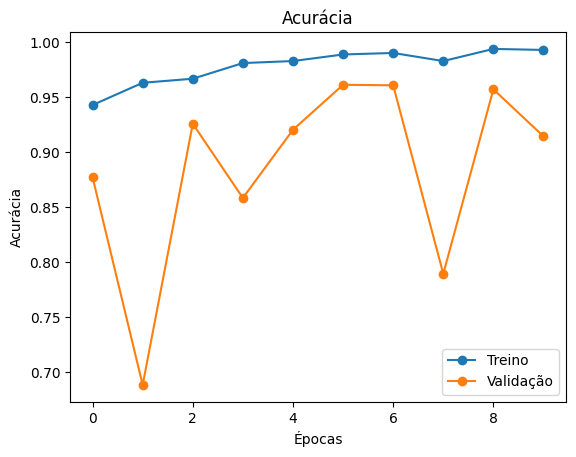

In [40]:

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

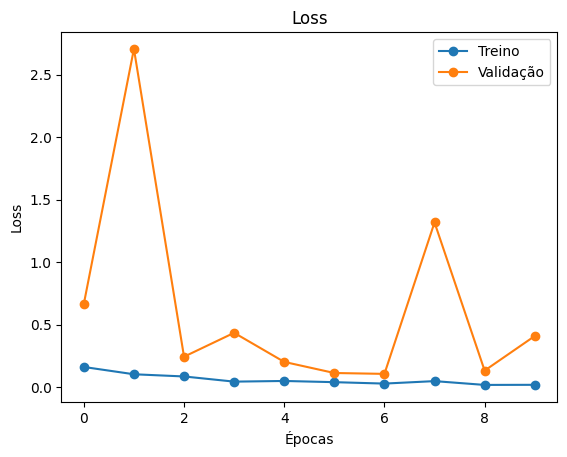

In [41]:
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Treino', 'Validação'])
plt.show()

In [42]:
import tensorflow as tf

x_test = tf.image.resize(x_test, (100, 100))
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1353
           1       0.82      0.99      0.90       821

    accuracy                           0.91      2174
   macro avg       0.91      0.93      0.91      2174
weighted avg       0.93      0.91      0.92      2174



In [103]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([3157, 1914], dtype=int64))
(array([0, 1]), array([1353,  821], dtype=int64))
